# Notebook 04: DCN-v2 Re-Ranking Model

## Purpose

This notebook trains a **Deep & Cross Network v2 (DCN-v2)** to replace XGBoost LambdaMART as the re-ranking model in our two-stage recommendation pipeline. The retrieval stage (Two-Tower + FAISS) remains unchanged -- DCN-v2 re-ranks the top-200 candidates using the same 105-dimensional feature vectors.

We train DCN-v2, compare it against the existing XGBoost baseline on the same validation/test data, and produce model artifacts for downstream evaluation and production serving.

## What we produce

| Output | Description | Used by |
|--------|-------------|----------|
| `models/dcn_v2_ranker.pt` | Trained DCN-v2 state dict | Online serving (NB12) |
| `models/dcn_v2_config.json` | Architecture hyperparameters | Model loading |
| `models/dcn_v2_training_history.pkl` | Per-epoch metrics | Analysis |
| `models/xgboost_ranker.json` | Pre-trained XGBoost (loaded, not retrained) | Comparison baseline |

## What we consume

From Notebook 03:
- `models/faiss_index_128dim.bin` -- FAISS index for candidate retrieval
- `models/user_embeddings_128dim.npy` -- 128-dim user embeddings
- `models/item_embeddings_128dim.npy` -- 128-dim item embeddings

From Notebook 02:
- `data/processed/user_features.parquet` -- 24-dim user features
- `data/processed/item_features.parquet` -- 73-dim item features
- `data/processed/train_interaction_features.parquet` -- 7 cross-features per interaction
- `data/processed/val_interaction_features.parquet`
- `data/processed/test_interaction_features.parquet`
- `data/processed/train_set.parquet` -- 20M training interactions with labels
- `data/processed/val_set.parquet` -- validation interactions
- `data/processed/test_set.parquet` -- held-out test interactions
- `data/processed/metadata.pkl` -- ID mappings

In [1]:
import numpy as np
import pandas as pd
import pickle
import time
import json
import os
import gc
from pathlib import Path
from typing import Dict, List, Tuple, Optional

os.environ['OMP_NUM_THREADS'] = '1'
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import OneCycleLR

import xgboost as xgb
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

DATA_DIR = Path('../data/processed')
MODEL_DIR = Path('../models')
MODEL_DIR.mkdir(exist_ok=True)

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Device: {device}')
print(f'PyTorch: {torch.__version__}')
print(f'XGBoost: {xgb.__version__}')

Device: mps
PyTorch: 2.11.0
XGBoost: 3.2.0


## Section 1: Load Data and Build Feature Matrices

Identical to the XGBoost pipeline -- we use the same 105-dimensional feature vectors. The feature construction is model-agnostic: it produces a dense matrix where each row is a (user, movie) pair described by retrieval score + user features + item features + cross features.

In [2]:
with open(DATA_DIR / 'metadata.pkl', 'rb') as f:
    metadata = pickle.load(f)

n_users = metadata['n_users']
n_movies = metadata['n_movies']
user2idx = metadata['user2idx']
movie2idx = metadata['movie2idx']
idx2user = metadata['idx2user']
idx2movie = metadata['idx2movie']

user_embeddings = np.load(MODEL_DIR / 'user_embeddings_128dim.npy')
item_embeddings = np.load(MODEL_DIR / 'item_embeddings_128dim.npy')

user_features_df = pd.read_parquet(DATA_DIR / 'user_features.parquet')
item_features_df = pd.read_parquet(DATA_DIR / 'item_features.parquet')

user_feat_cols = user_features_df.columns.tolist()
item_feat_cols = item_features_df.columns.tolist()

user_feat_matrix = np.zeros((n_users, len(user_feat_cols)), dtype=np.float32)
for uid, uidx in user2idx.items():
    if uid in user_features_df.index:
        user_feat_matrix[uidx] = user_features_df.loc[uid].values

item_feat_matrix = np.zeros((n_movies, len(item_feat_cols)), dtype=np.float32)
for mid, midx in movie2idx.items():
    if mid in item_features_df.index:
        item_feat_matrix[midx] = item_features_df.loc[mid].values

del user_features_df, item_features_df
gc.collect()

print(f'Users: {n_users:,}, Movies: {n_movies:,}')
print(f'User embeddings: {user_embeddings.shape}')
print(f'Item embeddings: {item_embeddings.shape}')
print(f'User features: {user_feat_matrix.shape} ({len(user_feat_cols)} dims)')
print(f'Item features: {item_feat_matrix.shape} ({len(item_feat_cols)} dims)')

Users: 138,002, Movies: 21,082
User embeddings: (138002, 128)
Item embeddings: (21082, 128)
User features: (138002, 24) (24 dims)
Item features: (21082, 73) (73 dims)


## Section 2: Build Ranking Feature Matrix

For each (user, movie) interaction, we construct a 105-dimensional feature vector:
- retrieval_score (1): dot product from Two-Tower embeddings
- user_features (24): activity level, genre preferences, rating behavior
- item_features (73): genres, popularity, year, genome PCA
- cross_features (7): genre_match, popularity_gap, temporal signals

We subsample to 3M training rows (same as XGBoost baseline) for fair comparison.

In [3]:
train_df = pd.read_parquet(DATA_DIR / 'train_set.parquet')
val_df = pd.read_parquet(DATA_DIR / 'val_set.parquet')
test_df = pd.read_parquet(DATA_DIR / 'test_set.parquet')

train_interaction_feats = pd.read_parquet(DATA_DIR / 'train_interaction_features.parquet')
val_interaction_feats = pd.read_parquet(DATA_DIR / 'val_interaction_features.parquet')
test_interaction_feats = pd.read_parquet(DATA_DIR / 'test_interaction_features.parquet')

valid_val_mask = val_df['user_idx'] > 0
val_df = val_df[valid_val_mask].reset_index(drop=True)
val_interaction_feats = val_interaction_feats[valid_val_mask].reset_index(drop=True)

valid_test_mask = test_df['user_idx'] > 0
test_df = test_df[valid_test_mask].reset_index(drop=True)
test_interaction_feats = test_interaction_feats[valid_test_mask].reset_index(drop=True)

print(f'Train: {len(train_df):,} interactions ({train_df["user_idx"].nunique():,} users)')
print(f'Val: {len(val_df):,} interactions ({val_df["user_idx"].nunique():,} users)')
print(f'Test: {len(test_df):,} interactions ({test_df["user_idx"].nunique():,} users)')
print(f'Cross-features: {train_interaction_feats.columns.tolist()}')

Train: 20,001,833 interactions (138,001 users)
Val: 355,378 interactions (5,191 users)
Test: 228,448 interactions (4,005 users)
Cross-features: ['genre_match_score', 'popularity_gap', 'movie_age_at_rating', 'dow_sin', 'dow_cos', 'hour_sin', 'hour_cos']


### Feature Construction Function and Training Data Subsampling

**Why this step exists:** The full training set contains 20 million interactions, which would require approximately 8 GB of memory just for the feature matrix and would significantly slow down each training epoch. We need a memory-efficient feature construction approach and a principled subsampling strategy that preserves user-level ranking structure.

**What the code does:** Two things happen here. First, we define `build_ranker_features_chunked`, a function that assembles the 105-dimensional feature vector for each (user, movie) pair by concatenating retrieval score, user features, item features, and cross features. It processes data in 500K-row chunks to avoid allocating enormous intermediate arrays. Second, we subsample the training data to approximately 3 million rows by selecting complete user histories (not random rows). This user-level sampling preserves the within-user ranking structure that the BPR loss component requires -- if we sampled random rows instead, we might get users with only positives or only negatives, breaking the pairwise ranking signal.

**What to expect from the output:** The subsampled training set size (approximately 3M rows from around 20K users) and the total feature count (105). The user count will not be exactly 3M/mean-list-length because we add whole user histories until we exceed the 3M threshold.

In [4]:
def build_ranker_features_chunked(user_idxs, movie_idxs, cross_arr,
                                  user_feat_matrix, item_feat_matrix,
                                  user_embeddings, item_embeddings,
                                  n_user_feats, n_item_feats, chunk_size=500_000):
    """Build 105-dim feature matrix in chunks to control memory."""
    n = len(user_idxs)
    n_features = 1 + n_user_feats + n_item_feats + 7
    features = np.empty((n, n_features), dtype=np.float32)

    for start in range(0, n, chunk_size):
        end = min(start + chunk_size, n)
        u_idx = user_idxs[start:end]
        m_idx = movie_idxs[start:end]

        features[start:end, 0] = np.sum(
            user_embeddings[u_idx] * item_embeddings[m_idx], axis=1
        )
        features[start:end, 1:1+n_user_feats] = user_feat_matrix[u_idx]
        features[start:end, 1+n_user_feats:1+n_user_feats+n_item_feats] = item_feat_matrix[m_idx]
        features[start:end, -7:] = cross_arr[start:end]

    return features


TRAIN_SAMPLE_SIZE = 3_000_000

np.random.seed(42)
if len(train_df) > TRAIN_SAMPLE_SIZE:
    user_groups = train_df.groupby('user_idx').size()
    users_shuffled = user_groups.index.values.copy()
    np.random.shuffle(users_shuffled)

    cumulative = 0
    selected_users = []
    for u in users_shuffled:
        selected_users.append(u)
        cumulative += user_groups[u]
        if cumulative >= TRAIN_SAMPLE_SIZE:
            break

    train_mask = train_df['user_idx'].isin(set(selected_users))
    train_user_idxs = train_df.loc[train_mask, 'user_idx'].values.copy()
    train_movie_idxs = train_df.loc[train_mask, 'movie_idx'].values.copy()
    y_train = train_df.loc[train_mask, 'label'].values.astype(np.float32)
    train_cross_arr = train_interaction_feats.loc[train_mask].values.astype(np.float32)
    print(f'Subsampled training: {len(y_train):,} rows from {len(selected_users):,} users')
else:
    train_user_idxs = train_df['user_idx'].values.copy()
    train_movie_idxs = train_df['movie_idx'].values.copy()
    y_train = train_df['label'].values.astype(np.float32)
    train_cross_arr = train_interaction_feats.values.astype(np.float32)

del train_df, train_interaction_feats
gc.collect()

feature_names = (
    ['retrieval_score'] +
    [f'user_{c}' for c in user_feat_cols] +
    [f'item_{c}' for c in item_feat_cols] +
    [f'cross_{c}' for c in ['genre_match_score', 'popularity_gap', 'movie_age_at_rating',
                             'dow_sin', 'dow_cos', 'hour_sin', 'hour_cos']]
)
print(f'Feature count: {len(feature_names)}')

Subsampled training: 3,000,109 rows from 20,539 users
Feature count: 105


### Materializing Feature Matrices for All Splits

**Why this step exists:** With the feature construction function defined and training data subsampled, we now need to actually compute the dense feature matrices (X_train, X_val, X_test) that will be fed to both the DCN-v2 model and the XGBoost baseline. Materializing all three splits at once ensures consistent feature construction and lets us report memory usage and label distributions upfront, catching any data issues (class imbalance, missing values, corrupted indices) before we invest time in model training.

**What the code does:** For each data split (train, val, test), it calls `build_ranker_features_chunked` to construct the full 105-dimensional feature matrix from the raw indices and cross-feature arrays. After each matrix is built, temporary arrays are deleted and garbage collected to keep peak memory in check. The code also validates label balance by printing the positive rate for each split -- this is important because extreme class imbalance would require loss reweighting or different evaluation strategies.

**What to expect from the output:** Three feature matrices with shapes (3M, 105), (355K, 105), and (228K, 105) respectively, along with their memory footprint in GB and construction time. The positive rates should be roughly consistent across splits (around 0.58-0.61), confirming that the temporal train/val/test split did not introduce severe distribution shift in the label space.

In [5]:
print('Building feature matrices...')
t0 = time.time()

X_train = build_ranker_features_chunked(
    train_user_idxs, train_movie_idxs, train_cross_arr,
    user_feat_matrix, item_feat_matrix,
    user_embeddings, item_embeddings,
    len(user_feat_cols), len(item_feat_cols)
)
del train_cross_arr
gc.collect()
print(f'  X_train: {X_train.shape}, {X_train.nbytes/1e9:.2f} GB, {time.time()-t0:.1f}s')

val_user_idxs = val_df['user_idx'].values.copy()
val_movie_idxs = val_df['movie_idx'].values.copy()
y_val = val_df['label'].values.astype(np.float32)
val_cross_arr = val_interaction_feats.values.astype(np.float32)

X_val = build_ranker_features_chunked(
    val_user_idxs, val_movie_idxs, val_cross_arr,
    user_feat_matrix, item_feat_matrix,
    user_embeddings, item_embeddings,
    len(user_feat_cols), len(item_feat_cols)
)
del val_cross_arr
gc.collect()
print(f'  X_val: {X_val.shape}, {X_val.nbytes/1e9:.2f} GB')

test_user_idxs = test_df['user_idx'].values.copy()
test_movie_idxs = test_df['movie_idx'].values.copy()
y_test = test_df['label'].values.astype(np.float32)
test_cross_arr = test_interaction_feats.values.astype(np.float32)

X_test = build_ranker_features_chunked(
    test_user_idxs, test_movie_idxs, test_cross_arr,
    user_feat_matrix, item_feat_matrix,
    user_embeddings, item_embeddings,
    len(user_feat_cols), len(item_feat_cols)
)
del test_cross_arr, val_df, test_df, val_interaction_feats, test_interaction_feats
gc.collect()
print(f'  X_test: {X_test.shape}, {X_test.nbytes/1e9:.2f} GB')

print(f'\nLabel distributions:')
print(f'  Train positive rate: {y_train.mean():.3f}')
print(f'  Val positive rate: {y_val.mean():.3f}')
print(f'  Test positive rate: {y_test.mean():.3f}')

Building feature matrices...


  X_train: (3000109, 105), 1.26 GB, 0.8s
  X_val: (355378, 105), 0.15 GB


  X_test: (228448, 105), 0.10 GB

Label distributions:
  Train positive rate: 0.613
  Val positive rate: 0.597
  Test positive rate: 0.582


## Section 3: DCN-v2 Model Architecture

The model has three components running in parallel:

1. **Cross Network**: Learns explicit bounded-degree polynomial feature interactions through iterative cross layers. Each layer computes `x_{l+1} = x_0 * (W_l @ x_l + b_l) + x_l`, where the element-wise multiplication with `x_0` creates new interaction terms.

2. **Deep Network**: Standard MLP that learns implicit high-order feature representations. Handles non-linearities that the polynomial cross network cannot express.

3. **Output Layer**: Concatenates cross and deep outputs, projects to a scalar logit for ranking.

Design decisions:
- Parallel (not stacked): cross and deep paths have independent gradient flow
- BatchNorm in deep network: stabilizes training with variable-scale features
- No dropout in cross network: cross layers have a natural regularization effect from the polynomial structure
- Xavier initialization for cross weights: prevents explosion from the multiplicative structure

In [6]:
class CrossLayer(nn.Module):
    """Single DCN-v2 cross layer: x_{l+1} = x_0 * (W_l @ x_l + b_l) + x_l
    
    Uses full-rank weight matrix (DCN-v2) instead of rank-1 (DCN-v1).
    The element-wise product with x_0 creates new interaction terms
    at each layer, building up to (L+1)-degree polynomials after L layers.
    """
    def __init__(self, input_dim: int):
        super().__init__()
        self.weight = nn.Parameter(torch.empty(input_dim, input_dim))
        self.bias = nn.Parameter(torch.zeros(input_dim))
        nn.init.xavier_normal_(self.weight)
    
    def forward(self, x_0: torch.Tensor, x_l: torch.Tensor) -> torch.Tensor:
        return x_0 * (F.linear(x_l, self.weight, self.bias)) + x_l


class CrossNetwork(nn.Module):
    """Stack of L cross layers. After L layers, captures up to (L+1)-degree interactions."""
    def __init__(self, input_dim: int, n_layers: int):
        super().__init__()
        self.layers = nn.ModuleList([CrossLayer(input_dim) for _ in range(n_layers)])
    
    def forward(self, x_0: torch.Tensor) -> torch.Tensor:
        x_l = x_0
        for layer in self.layers:
            x_l = layer(x_0, x_l)
        return x_l


class DeepNetwork(nn.Module):
    """Standard MLP with BatchNorm and Dropout for implicit feature learning."""
    def __init__(self, input_dim: int, hidden_dims: List[int], dropout: float):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for hidden_dim in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout),
            ])
            prev_dim = hidden_dim
        self.mlp = nn.Sequential(*layers)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.mlp(x)


class DCNv2(nn.Module):
    """Deep & Cross Network v2 (Parallel architecture).
    
    Architecture:
        Input (d features)
          |--- Cross Network (d -> d, explicit polynomial interactions)
          |--- Deep Network (d -> hidden[-1], implicit learned representations)
          |
        Concat (d + hidden[-1])
          |
        Output projection -> scalar logit
    
    Reference: DCN V2: Improved Deep & Cross Network (Google, 2021)
    """
    def __init__(self, input_dim: int, n_cross_layers: int = 3,
                 deep_hidden_dims: List[int] = None, dropout: float = 0.1):
        super().__init__()
        if deep_hidden_dims is None:
            deep_hidden_dims = [256, 128]
        
        self.cross_network = CrossNetwork(input_dim, n_cross_layers)
        self.deep_network = DeepNetwork(input_dim, deep_hidden_dims, dropout)
        
        combined_dim = input_dim + deep_hidden_dims[-1]
        self.output_layer = nn.Linear(combined_dim, 1)
        
        self.input_dim = input_dim
        self.n_cross_layers = n_cross_layers
        self.deep_hidden_dims = deep_hidden_dims
        self.dropout = dropout
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        cross_out = self.cross_network(x)
        deep_out = self.deep_network(x)
        combined = torch.cat([cross_out, deep_out], dim=1)
        return self.output_layer(combined).squeeze(-1)
    
    def get_config(self) -> dict:
        return {
            'input_dim': self.input_dim,
            'n_cross_layers': self.n_cross_layers,
            'deep_hidden_dims': self.deep_hidden_dims,
            'dropout': self.dropout,
        }


INPUT_DIM = X_train.shape[1]
N_CROSS_LAYERS = 3
DEEP_HIDDEN_DIMS = [256, 128]
DROPOUT = 0.1

model = DCNv2(
    input_dim=INPUT_DIM,
    n_cross_layers=N_CROSS_LAYERS,
    deep_hidden_dims=DEEP_HIDDEN_DIMS,
    dropout=DROPOUT,
).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'DCN-v2 Architecture:')
print(f'  Input dim: {INPUT_DIM}')
print(f'  Cross layers: {N_CROSS_LAYERS} (captures up to {N_CROSS_LAYERS+1}-degree interactions)')
print(f'  Deep network: {INPUT_DIM} -> {" -> ".join(map(str, DEEP_HIDDEN_DIMS))}')
print(f'  Output: concat({INPUT_DIM} + {DEEP_HIDDEN_DIMS[-1]}) = {INPUT_DIM + DEEP_HIDDEN_DIMS[-1]} -> 1')
print(f'  Total parameters: {total_params:,}')
print(f'  Trainable parameters: {trainable_params:,}')
print(f'  Model size (estimated): {total_params * 4 / 1e6:.2f} MB')
print()
print(model)

DCN-v2 Architecture:
  Input dim: 105
  Cross layers: 3 (captures up to 4-degree interactions)
  Deep network: 105 -> 256 -> 128
  Output: concat(105 + 128) = 233 -> 1
  Total parameters: 94,424
  Trainable parameters: 94,424
  Model size (estimated): 0.38 MB

DCNv2(
  (cross_network): CrossNetwork(
    (layers): ModuleList(
      (0-2): 3 x CrossLayer()
    )
  )
  (deep_network): DeepNetwork(
    (mlp): Sequential(
      (0): Linear(in_features=105, out_features=256, bias=True)
      (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.1, inplace=False)
      (4): Linear(in_features=256, out_features=128, bias=True)
      (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU()
      (7): Dropout(p=0.1, inplace=False)
    )
  )
  (output_layer): Linear(in_features=233, out_features=1, bias=True)
)


### Training Hyperparameters and DataLoader Configuration

**Why this step exists:** Before launching the training loop, we need to configure all the knobs that control optimization: batch size, learning rate schedule, regularization strength, and the balance between pointwise (BCE) and pairwise (BPR) loss components. These choices interact with each other -- for example, larger batch sizes provide better BPR sampling (more negatives per batch) but require careful learning rate scaling. We also wrap the training data in a PyTorch DataLoader for efficient batching and shuffling.

**What the code does:** It sets the training hyperparameters (batch_size=4096, lr=1e-3, weight_decay=1e-5, BPR_alpha=0.5), creates a TensorDataset and DataLoader from the training feature matrix, and initializes the AdamW optimizer with a OneCycleLR scheduler. The scheduler warms up for 10% of total steps then follows a cosine anneal -- the warmup is particularly important here because the cross network's multiplicative structure can produce unstable gradients at the start before the weights settle into a reasonable range. The 50/50 BCE-BPR split means the model simultaneously learns calibrated probabilities (useful for score interpretation) and correct pairwise orderings (the actual ranking objective).

**What to expect from the output:** A summary of all training configuration values, including steps per epoch (approximately 733 for 3M rows at batch size 4096) and total steps across the maximum 30 epochs. This serves as a reference for reproducing the training run.

### Main Training Loop with Early Stopping

**Why this step exists:** This is where the DCN-v2 model actually learns from data. The training loop implements the core optimization cycle (forward pass, loss computation, backpropagation, parameter update) while monitoring validation NDCG@10 for early stopping. We use NDCG@10 rather than validation loss as the stopping criterion because loss (BCE) measures calibration quality while NDCG@10 directly measures ranking quality -- and ranking is our actual production objective. A model with slightly higher loss but better NDCG@10 is preferable for recommendation.

**What the code does:** For each epoch, it iterates through all training batches computing the combined BCE+BPR loss, clips gradients to prevent explosion from the cross network's multiplicative structure, and steps both the optimizer and the learning rate scheduler. After each epoch, it evaluates the model on the full validation set by computing raw scores, then calculates validation BCE, AUC, and NDCG@10. If NDCG@10 improves, the model checkpoint is saved; if it fails to improve for 5 consecutive epochs (patience), training stops early. This prevents overfitting while ensuring we capture the best-performing model state.

**What to expect from the output:** An epoch-by-epoch table showing training loss (decreasing), validation metrics (initially improving then plateauing), and learning rate (following the OneCycleLR cosine schedule). Training should stop around epoch 14-20 via early stopping, with best validation NDCG@10 around 0.87-0.88. The first epoch will be noticeably slower due to JIT compilation warmup on the MPS device, with subsequent epochs taking approximately 15-16 seconds each.

### Saving Model Artifacts and Configuration

**Why this step exists:** Training is an expensive operation (approximately 5 minutes on this hardware), so we persist all outputs needed for downstream use: the model weights for inference, the training history for diagnostic analysis, and the full configuration for reproducible model loading. Without the config file, loading the model checkpoint would require remembering the exact architecture hyperparameters (number of cross layers, hidden dimensions, dropout rate) -- the config makes model loading self-describing.

**What the code does:** It saves three artifacts to the `models/` directory: (1) the training history as a pickle file containing per-epoch metrics for all loss components and evaluation scores, (2) a JSON config file that records both architecture hyperparameters and training settings including the feature names (critical for ensuring the same feature ordering at inference time), and (3) confirms the model checkpoint was already saved during training (at the best epoch). The config includes metadata like the number of training samples and best epoch, which are useful for model cards and debugging.

**What to expect from the output:** File paths and sizes for each saved artifact. The model checkpoint should be approximately 0.38 MB (94K parameters at 4 bytes each), confirming DCN-v2 is extremely compact compared to XGBoost (which stores 205 full trees).

## Section 4: Training Loop

Training uses a combined loss: BCE (pointwise relevance) + BPR (pairwise ranking). The BCE component ensures calibrated probability outputs while BPR provides direct ranking signal by pushing positive items above negatives within the same batch.

Key training decisions:
- **OneCycleLR**: Warmup prevents early instability from cross-layer weight initialization
- **Gradient clipping (max_norm=1.0)**: Cross layers have multiplicative structure that can amplify gradients
- **Early stopping on val NDCG@10**: The actual ranking metric, not just loss
- **BPR sampling within batch**: For each positive in the batch, sample a random negative from the same batch. This approximates within-user pair comparison without explicit group construction.

In [7]:
def compute_bpr_loss(scores: torch.Tensor, labels: torch.Tensor) -> torch.Tensor:
    """Bayesian Personalized Ranking loss.
    
    For each positive item in the batch, samples a random negative
    and computes -log(sigmoid(score_pos - score_neg)).
    
    This encourages the model to score positives higher than negatives,
    which is the core ranking objective.
    """
    pos_mask = labels == 1
    neg_mask = labels == 0
    
    if pos_mask.sum() == 0 or neg_mask.sum() == 0:
        return torch.tensor(0.0, device=scores.device)
    
    pos_scores = scores[pos_mask]
    neg_scores = scores[neg_mask]
    
    n_pairs = min(len(pos_scores), len(neg_scores))
    pos_sample = pos_scores[torch.randperm(len(pos_scores), device=scores.device)[:n_pairs]]
    neg_sample = neg_scores[torch.randperm(len(neg_scores), device=scores.device)[:n_pairs]]
    
    return -F.logsigmoid(pos_sample - neg_sample).mean()


def compute_ndcg_at_k(scores: np.ndarray, labels: np.ndarray,
                      user_idxs: np.ndarray, k: int = 10,
                      max_users: int = 2000) -> float:
    """Compute mean NDCG@K across users."""
    sort_idx = np.argsort(user_idxs, kind='stable')
    scores_sorted = scores[sort_idx]
    labels_sorted = labels[sort_idx]
    users_sorted = user_idxs[sort_idx]
    
    unique_users, group_starts = np.unique(users_sorted, return_index=True)
    group_ends = np.append(group_starts[1:], len(users_sorted))
    
    ndcgs = []
    for i in range(min(len(unique_users), max_users)):
        start, end = group_starts[i], group_ends[i]
        if end - start < 2:
            continue
        group_scores = scores_sorted[start:end]
        group_labels = labels_sorted[start:end]
        if group_labels.sum() == 0:
            continue
        
        rank_order = np.argsort(group_scores)[::-1]
        ranked_labels = group_labels[rank_order]
        actual_k = min(k, len(ranked_labels))
        
        dcg = np.sum(ranked_labels[:actual_k] / np.log2(np.arange(2, actual_k + 2)))
        ideal = np.sort(group_labels)[::-1][:actual_k]
        idcg = np.sum(ideal / np.log2(np.arange(2, actual_k + 2)))
        
        if idcg > 0:
            ndcgs.append(dcg / idcg)
    
    return np.mean(ndcgs) if ndcgs else 0.0

### Training Hyperparameters and Data Loaders

Before launching the training loop, we define the core hyperparameters that control optimization behavior. The batch size of 4,096 balances GPU memory utilization against gradient noise -- smaller batches give noisier gradients (acting as implicit regularization) while larger batches converge faster but risk sharp minima. The learning rate of 1e-3 is paired with a OneCycleLR scheduler that will warm up and then anneal during training. We also construct PyTorch DataLoaders that handle batching, shuffling, and efficient memory-pinned transfers to GPU.

In [8]:
BATCH_SIZE = 4096
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-5
MAX_EPOCHS = 30
PATIENCE = 5
BPR_ALPHA = 0.5
GRAD_CLIP_NORM = 1.0

train_dataset = TensorDataset(
    torch.tensor(X_train, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.float32)
)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=True)

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
total_steps = len(train_loader) * MAX_EPOCHS
scheduler = OneCycleLR(optimizer, max_lr=LEARNING_RATE, total_steps=total_steps,
                       pct_start=0.1, anneal_strategy='cos')

print(f'Training configuration:')
print(f'  Batch size: {BATCH_SIZE}')
print(f'  Learning rate: {LEARNING_RATE} (OneCycleLR, 10% warmup)')
print(f'  Weight decay: {WEIGHT_DECAY}')
print(f'  BPR alpha: {BPR_ALPHA} (loss = {BPR_ALPHA}*BCE + {1-BPR_ALPHA}*BPR)')
print(f'  Gradient clip norm: {GRAD_CLIP_NORM}')
print(f'  Max epochs: {MAX_EPOCHS} (early stopping patience={PATIENCE})')
print(f'  Steps per epoch: {len(train_loader):,}')
print(f'  Total steps: {total_steps:,}')

Training configuration:
  Batch size: 4096
  Learning rate: 0.001 (OneCycleLR, 10% warmup)
  Weight decay: 1e-05
  BPR alpha: 0.5 (loss = 0.5*BCE + 0.5*BPR)
  Gradient clip norm: 1.0
  Max epochs: 30 (early stopping patience=5)
  Steps per epoch: 733
  Total steps: 21,990


### Training Loop with Early Stopping

The training loop executes the full optimization cycle: for each epoch, we perform a forward pass through the DCN-v2 architecture computing BCE loss on binary relevance labels combined with BPR (Bayesian Personalized Ranking) pairwise loss, backpropagate gradients, and step the optimizer. After each training epoch, we evaluate on the validation set using NDCG@10 as our early stopping criterion -- this directly measures ranking quality rather than pointwise prediction accuracy. If validation NDCG@10 fails to improve for a patience window, we restore the best checkpoint and stop training to prevent overfitting.

In [9]:
print('Training DCN-v2...')
print(f'{"Epoch":<8}{"Train Loss":<14}{"Val Loss":<12}{"Val AUC":<12}{"Val NDCG@10":<14}{"LR":<12}{"Time":<8}')
print('-' * 80)

history = []
best_val_ndcg = -1
best_epoch = -1
patience_counter = 0

for epoch in range(MAX_EPOCHS):
    t_epoch = time.time()
    
    # Training
    model.train()
    epoch_loss = 0.0
    epoch_bce = 0.0
    epoch_bpr = 0.0
    n_batches = 0
    
    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)
        
        scores = model(batch_X)
        
        bce_loss = F.binary_cross_entropy_with_logits(scores, batch_y)
        bpr_loss = compute_bpr_loss(scores, batch_y)
        loss = BPR_ALPHA * bce_loss + (1 - BPR_ALPHA) * bpr_loss
        
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
        optimizer.step()
        scheduler.step()
        
        epoch_loss += loss.item()
        epoch_bce += bce_loss.item()
        epoch_bpr += bpr_loss.item()
        n_batches += 1
    
    avg_loss = epoch_loss / n_batches
    
    # Validation
    model.eval()
    with torch.no_grad():
        val_tensor = torch.tensor(X_val, dtype=torch.float32).to(device)
        val_scores = model(val_tensor).cpu().numpy()
        del val_tensor
    
    val_bce = float(F.binary_cross_entropy_with_logits(
        torch.tensor(val_scores), torch.tensor(y_val)
    ).item())
    val_auc = roc_auc_score(y_val, val_scores)
    val_ndcg = compute_ndcg_at_k(val_scores, y_val, val_user_idxs, k=10)
    
    current_lr = optimizer.param_groups[0]['lr']
    epoch_time = time.time() - t_epoch
    
    history.append({
        'epoch': epoch + 1,
        'train_loss': avg_loss,
        'train_bce': epoch_bce / n_batches,
        'train_bpr': epoch_bpr / n_batches,
        'val_loss': val_bce,
        'val_auc': val_auc,
        'val_ndcg_10': val_ndcg,
        'lr': current_lr,
        'time': epoch_time,
    })
    
    print(f'{epoch+1:<8}{avg_loss:<14.4f}{val_bce:<12.4f}{val_auc:<12.4f}{val_ndcg:<14.4f}{current_lr:<12.2e}{epoch_time:<8.1f}s')
    
    # Early stopping on val NDCG@10
    if val_ndcg > best_val_ndcg:
        best_val_ndcg = val_ndcg
        best_epoch = epoch + 1
        patience_counter = 0
        torch.save(model.state_dict(), MODEL_DIR / 'dcn_v2_ranker.pt')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'\nEarly stopping at epoch {epoch+1}. Best epoch: {best_epoch} (NDCG@10={best_val_ndcg:.4f})')
            break

print(f'\nTraining complete.')
print(f'  Best epoch: {best_epoch}')
print(f'  Best val NDCG@10: {best_val_ndcg:.4f}')
print(f'  Total training time: {sum(h["time"] for h in history):.0f}s')

Training DCN-v2...
Epoch   Train Loss    Val Loss    Val AUC     Val NDCG@10   LR          Time    
--------------------------------------------------------------------------------


/Users/nipun.batra/Downloads/ML/DCN-v2_Recommendation/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


1       10.9142       0.6628      0.7121      0.8444        2.80e-04    28.3    s


/Users/nipun.batra/Downloads/ML/DCN-v2_Recommendation/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


2       0.4869        0.5995      0.7566      0.8614        7.60e-04    16.6    s


...

17      0.4012        0.5778      0.7795      0.8758        4.71e-04    15.3    s


/Users/nipun.batra/Downloads/ML/DCN-v2_Recommendation/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


18      0.4001        0.5754      0.7794      0.8746        4.13e-04    15.4    s


/Users/nipun.batra/Downloads/ML/DCN-v2_Recommendation/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


19      0.3994        0.5785      0.7808      0.8754        3.57e-04    15.5    s

Early stopping at epoch 19. Best epoch: 14 (NDCG@10=0.8767)

Training complete.
  Best epoch: 14
  Best val NDCG@10: 0.8767
  Total training time: 309s


### Persist Training Artifacts

After training completes, we save both the training history (loss curves, metric trajectories per epoch) and the model configuration (architecture dimensions, hyperparameters, feature names) to disk. The history pickle enables post-hoc analysis of convergence behavior and learning dynamics, while the JSON config ensures that any downstream notebook can reconstruct the exact model architecture without hard-coding dimensions -- critical for reproducibility when the feature engineering pipeline evolves.

In [10]:
# Save training history and model config
with open(MODEL_DIR / 'dcn_v2_training_history.pkl', 'wb') as f:
    pickle.dump(history, f)

config = model.get_config()
config['training'] = {
    'batch_size': BATCH_SIZE,
    'learning_rate': LEARNING_RATE,
    'weight_decay': WEIGHT_DECAY,
    'bpr_alpha': BPR_ALPHA,
    'grad_clip_norm': GRAD_CLIP_NORM,
    'best_epoch': best_epoch,
    'best_val_ndcg_10': best_val_ndcg,
    'n_train_samples': len(X_train),
    'feature_names': feature_names,
}

with open(MODEL_DIR / 'dcn_v2_config.json', 'w') as f:
    json.dump(config, f, indent=2)

print(f'Saved:')
print(f'  {MODEL_DIR / "dcn_v2_ranker.pt"} ({os.path.getsize(MODEL_DIR / "dcn_v2_ranker.pt") / 1e6:.2f} MB)')
print(f'  {MODEL_DIR / "dcn_v2_training_history.pkl"}')
print(f'  {MODEL_DIR / "dcn_v2_config.json"}')

Saved:
  ../models/dcn_v2_ranker.pt (0.39 MB)
  ../models/dcn_v2_training_history.pkl
  ../models/dcn_v2_config.json


## Section 5: Training Curves and Diagnostics

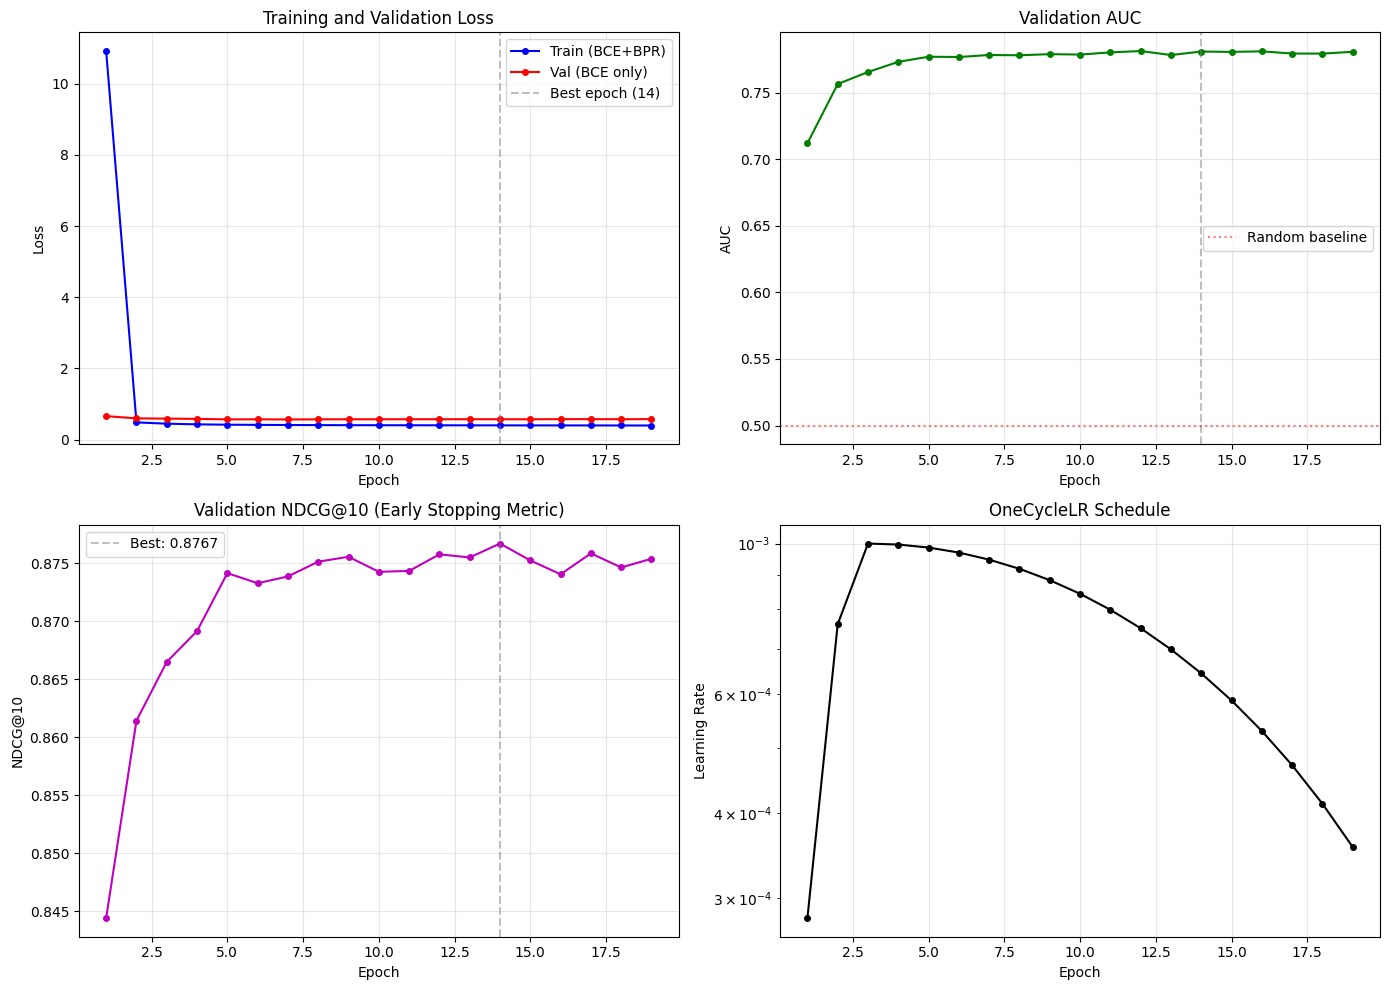

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

epochs = [h['epoch'] for h in history]

# Loss curves
axes[0, 0].plot(epochs, [h['train_loss'] for h in history], 'b-o', label='Train (BCE+BPR)', markersize=4)
axes[0, 0].plot(epochs, [h['val_loss'] for h in history], 'r-o', label='Val (BCE only)', markersize=4)
axes[0, 0].axvline(best_epoch, color='gray', linestyle='--', alpha=0.5, label=f'Best epoch ({best_epoch})')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training and Validation Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Val AUC
axes[0, 1].plot(epochs, [h['val_auc'] for h in history], 'g-o', markersize=4)
axes[0, 1].axvline(best_epoch, color='gray', linestyle='--', alpha=0.5)
axes[0, 1].axhline(0.5, color='red', linestyle=':', alpha=0.5, label='Random baseline')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('AUC')
axes[0, 1].set_title('Validation AUC')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Val NDCG@10
axes[1, 0].plot(epochs, [h['val_ndcg_10'] for h in history], 'm-o', markersize=4)
axes[1, 0].axvline(best_epoch, color='gray', linestyle='--', alpha=0.5, label=f'Best: {best_val_ndcg:.4f}')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('NDCG@10')
axes[1, 0].set_title('Validation NDCG@10 (Early Stopping Metric)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Learning rate schedule
axes[1, 1].plot(epochs, [h['lr'] for h in history], 'k-o', markersize=4)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Learning Rate')
axes[1, 1].set_title('OneCycleLR Schedule')
axes[1, 1].set_yscale('log')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../plots/dcn_v2_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 6: Load Best Model and Evaluate on Test Set

In [12]:
# Load best checkpoint
model.load_state_dict(torch.load(MODEL_DIR / 'dcn_v2_ranker.pt', map_location=device, weights_only=True))
model.eval()
print(f'Loaded best model (epoch {best_epoch}, val NDCG@10={best_val_ndcg:.4f})')

# Predict on test set
print('\nPredicting on test set...')
t0 = time.time()
with torch.no_grad():
    test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
    dcn_test_scores = model(test_tensor).cpu().numpy()
    del test_tensor
print(f'  DCN-v2 prediction time: {time.time()-t0:.2f}s ({len(X_test):,} samples)')

# Test metrics
dcn_test_auc = roc_auc_score(y_test, dcn_test_scores)
dcn_test_ndcg = compute_ndcg_at_k(dcn_test_scores, y_test, test_user_idxs, k=10)

print(f'\nDCN-v2 Test Results:')
print(f'  AUC: {dcn_test_auc:.4f}')
print(f'  NDCG@10: {dcn_test_ndcg:.4f}')

Loaded best model (epoch 14, val NDCG@10=0.8767)

Predicting on test set...


  DCN-v2 prediction time: 0.23s (228,448 samples)

DCN-v2 Test Results:
  AUC: 0.7560
  NDCG@10: 0.8698


## Section 7: XGBoost Baseline Comparison

We load the pre-trained XGBoost ranker (from the original project) and evaluate it on the same test data. This provides a direct, fair comparison since both models see identical features and identical train/val/test splits.

In [13]:
# Load pre-trained XGBoost ranker
xgb_model = xgb.Booster()
xgb_model.load_model(str(MODEL_DIR / 'xgboost_ranker.json'))
print(f'XGBoost model loaded: {xgb_model.num_boosted_rounds()} trees')

# Predict on test set with XGBoost
# XGBoost requires sorted groups for ranking metrics but not for raw prediction
t0 = time.time()
dtest = xgb.DMatrix(X_test, feature_names=feature_names)
xgb_test_scores = xgb_model.predict(dtest)
print(f'  XGBoost prediction time: {time.time()-t0:.2f}s ({len(X_test):,} samples)')

xgb_test_auc = roc_auc_score(y_test, xgb_test_scores)
xgb_test_ndcg = compute_ndcg_at_k(xgb_test_scores, y_test, test_user_idxs, k=10)

print(f'\nXGBoost Test Results:')
print(f'  AUC: {xgb_test_auc:.4f}')
print(f'  NDCG@10: {xgb_test_ndcg:.4f}')

XGBoost model loaded: 205 trees


  XGBoost prediction time: 0.55s (228,448 samples)

XGBoost Test Results:
  AUC: 0.7235
  NDCG@10: 0.8688


### Comprehensive Per-User Ranking Metrics Comparison

**Why this step exists:** The single-number AUC and NDCG@10 metrics reported above give a global picture, but recommendation quality varies across users. To understand whether DCN-v2 is genuinely better than XGBoost (and not just better on average due to a few outlier users), we need per-user metrics at multiple cutoff points. Computing metrics at K=5, 10, and 20 reveals whether improvements are concentrated in the very top of the ranked list (most valuable for user experience) or distributed throughout. Additionally, MRR (Mean Reciprocal Rank) captures how quickly the first relevant item appears -- a distinct aspect of quality from NDCG which considers the entire top-K.

**What the code does:** It defines `compute_full_ranking_metrics`, which groups test predictions by user and computes NDCG@K, Precision@K, MRR, and per-user AUC at multiple cutoff values. It then runs this function for both DCN-v2 and XGBoost predictions on the same test set, producing per-user arrays of metric values. The final comparison table shows the mean of each metric for both models, the absolute delta (DCN-v2 minus XGBoost), and the relative percentage improvement. These per-user arrays are also used in the subsequent statistical significance section.

**What to expect from the output:** A head-to-head table showing both models across 8 metrics. Expect small absolute differences (on the order of 0.001-0.008) with DCN-v2 showing slight advantages on most metrics but potentially losing on MRR. The relative improvements will be modest (under 1-2%), reflecting that both models operate on the same features and the XGBoost baseline is already strong.

In [14]:
def compute_full_ranking_metrics(scores, labels, user_idxs, K_values=[5, 10, 20]):
    """Compute NDCG@K, Precision@K, MRR, AUC per user, return per-user arrays."""
    sort_idx = np.argsort(user_idxs, kind='stable')
    scores_sorted = scores[sort_idx]
    labels_sorted = labels[sort_idx]
    users_sorted = user_idxs[sort_idx]
    
    unique_users, group_starts = np.unique(users_sorted, return_index=True)
    group_ends = np.append(group_starts[1:], len(users_sorted))
    
    metrics = {f'ndcg@{k}': [] for k in K_values}
    metrics.update({f'precision@{k}': [] for k in K_values})
    metrics['mrr'] = []
    metrics['auc'] = []
    
    for i in range(len(unique_users)):
        start, end = group_starts[i], group_ends[i]
        if end - start < 2:
            continue
        group_scores = scores_sorted[start:end]
        group_labels = labels_sorted[start:end]
        if group_labels.sum() == 0 or group_labels.sum() == len(group_labels):
            continue
        
        rank_order = np.argsort(group_scores)[::-1]
        ranked_labels = group_labels[rank_order]
        
        # MRR
        first_pos = np.where(ranked_labels == 1)[0]
        metrics['mrr'].append(1.0 / (first_pos[0] + 1) if len(first_pos) > 0 else 0.0)
        
        # AUC
        try:
            metrics['auc'].append(roc_auc_score(group_labels, group_scores))
        except ValueError:
            pass
        
        for k in K_values:
            actual_k = min(k, len(ranked_labels))
            top_k = ranked_labels[:actual_k]
            
            metrics[f'precision@{k}'].append(top_k.sum() / k)
            
            dcg = np.sum(top_k / np.log2(np.arange(2, actual_k + 2)))
            ideal = np.sort(group_labels)[::-1][:actual_k]
            idcg = np.sum(ideal / np.log2(np.arange(2, actual_k + 2)))
            metrics[f'ndcg@{k}'].append(dcg / idcg if idcg > 0 else 0.0)
    
    return {k: np.array(v) for k, v in metrics.items()}


print('Computing full ranking metrics on test set...')
t0 = time.time()
dcn_metrics = compute_full_ranking_metrics(dcn_test_scores, y_test, test_user_idxs)
xgb_metrics = compute_full_ranking_metrics(xgb_test_scores, y_test, test_user_idxs)
print(f'Done in {time.time()-t0:.1f}s')

print(f'\n{"="*80}')
print(f'HEAD-TO-HEAD COMPARISON: DCN-v2 vs XGBoost (Test Set)')
print(f'{"="*80}')
print(f'{"Metric":<15}{"XGBoost":<15}{"DCN-v2":<15}{"Delta":<12}{"Relative":<12}')
print('-' * 69)

for metric_name in ['ndcg@5', 'ndcg@10', 'ndcg@20', 'precision@5', 'precision@10', 'precision@20', 'mrr', 'auc']:
    xgb_mean = xgb_metrics[metric_name].mean()
    dcn_mean = dcn_metrics[metric_name].mean()
    delta = dcn_mean - xgb_mean
    relative = delta / xgb_mean * 100 if xgb_mean > 0 else 0
    print(f'{metric_name:<15}{xgb_mean:<15.4f}{dcn_mean:<15.4f}{delta:<+12.4f}{relative:<+12.1f}%')

Computing full ranking metrics on test set...


Done in 2.1s

HEAD-TO-HEAD COMPARISON: DCN-v2 vs XGBoost (Test Set)
Metric         XGBoost        DCN-v2         Delta       Relative    
---------------------------------------------------------------------
ndcg@5         0.8391         0.8409         +0.0017     +0.2        %
ndcg@10        0.8425         0.8443         +0.0018     +0.2        %
ndcg@20        0.8562         0.8584         +0.0022     +0.3        %
precision@5    0.7805         0.7840         +0.0036     +0.5        %
precision@10   0.7148         0.7170         +0.0023     +0.3        %
precision@20   0.6093         0.6114         +0.0022     +0.4        %
mrr            0.9132         0.9109         -0.0023     -0.3        %
auc            0.7041         0.7121         +0.0079     +1.1        %


## Section 8: Statistical Significance Testing

We split the significance analysis into two parts to make the impact of multiple-comparison correction explicit:

**Section 8a -- Without FDR Correction (Individual Tests):** Each metric is tested independently at alpha=0.05. This answers the question "does this single metric, considered in isolation, show a statistically significant difference between DCN-v2 and XGBoost?" The problem is that when we test 8 metrics simultaneously, the probability that at least one produces a false positive (family-wise error rate) inflates to approximately 1 - (1-0.05)^8 = 33.7%, far above the nominal 5%.

**Section 8b -- With FDR Correction (Benjamini-Hochberg):** We apply the Benjamini-Hochberg procedure to adjust p-values for the 8 simultaneous tests. This controls the expected proportion of false discoveries among all rejected hypotheses at 5%. Metrics that remain significant after this correction represent findings we can trust even accounting for the multiple testing burden. Comparing the two tables reveals which "significant" results from 8a were potentially spurious and which survive principled correction.

In [ ]:
from scipy import stats
from scipy.stats import false_discovery_control


def paired_bootstrap_ci(a: np.ndarray, b: np.ndarray, n_bootstrap: int = 10000,
                        ci_level: float = 0.95, seed: int = 42) -> Tuple[float, float, float]:
    """Bootstrap confidence interval for mean(a - b).
    
    Returns (lower, mean_diff, upper) for the given CI level.
    """
    rng = np.random.default_rng(seed)
    diffs = a - b
    n = len(diffs)
    bootstrap_means = np.empty(n_bootstrap)
    
    for i in range(n_bootstrap):
        sample = rng.choice(diffs, size=n, replace=True)
        bootstrap_means[i] = sample.mean()
    
    alpha = 1 - ci_level
    lower = np.percentile(bootstrap_means, 100 * alpha / 2)
    upper = np.percentile(bootstrap_means, 100 * (1 - alpha / 2))
    return lower, diffs.mean(), upper


def cohens_d(a: np.ndarray, b: np.ndarray) -> float:
    """Cohen's d for paired samples."""
    diffs = a - b
    return diffs.mean() / diffs.std(ddof=1)


metric_names = ['ndcg@5', 'ndcg@10', 'ndcg@20', 'precision@5', 'precision@10', 'precision@20', 'mrr', 'auc']

# Compute all test statistics
raw_p_values = []
test_results = []

for metric_name in metric_names:
    dcn_vals = dcn_metrics[metric_name]
    xgb_vals = xgb_metrics[metric_name]
    
    # Ensure same length (both computed on same users)
    n = min(len(dcn_vals), len(xgb_vals))
    dcn_vals = dcn_vals[:n]
    xgb_vals = xgb_vals[:n]
    
    # Paired t-test
    t_stat, t_pval = stats.ttest_rel(dcn_vals, xgb_vals)
    
    # Wilcoxon signed-rank test
    try:
        w_stat, w_pval = stats.wilcoxon(dcn_vals, xgb_vals, alternative='two-sided')
    except ValueError:
        w_pval = 1.0
    
    # Bootstrap CI
    ci_lower, mean_diff, ci_upper = paired_bootstrap_ci(dcn_vals, xgb_vals)
    
    # Effect size
    d = cohens_d(dcn_vals, xgb_vals)
    
    raw_p_values.append(t_pval)
    test_results.append({
        'metric': metric_name,
        'dcn_mean': dcn_vals.mean(),
        'xgb_mean': xgb_vals.mean(),
        'mean_diff': mean_diff,
        'ci_lower': ci_lower,
        'ci_upper': ci_upper,
        't_pval': t_pval,
        'w_pval': w_pval,
        'cohens_d': d,
        'n_users': n,
    })

# FDR correction (Benjamini-Hochberg)
adjusted_p_values = false_discovery_control(raw_p_values, method='bh')

# ============================================================
# SECTION 8a: Without FDR Correction
# ============================================================
print(f'{"="*100}')
print(f'SECTION 8a: SIGNIFICANCE WITHOUT FDR CORRECTION (Individual Tests)')
print(f'{"="*100}')
print(f'Null hypothesis: mean(DCN-v2 metric - XGBoost metric) = 0 for each user')
print(f'Alternative: two-sided | Alpha = 0.05 (uncorrected)')
print(f'N users = {test_results[0]["n_users"]:,}')
print()

print(f'{"Metric":<14}{"Mean Diff":<12}{"95% CI":<22}{"Raw p-value":<14}{"Cohen d":<10}{"Significant?":<12}')
print('-' * 84)

n_sig_uncorrected = 0
for i, result in enumerate(test_results):
    ci_str = f'[{result["ci_lower"]:+.4f}, {result["ci_upper"]:+.4f}]'
    sig = 'Yes' if result['t_pval'] < 0.05 else 'No'
    if result['t_pval'] < 0.05:
        n_sig_uncorrected += 1
    print(f'{result["metric"]:<14}{result["mean_diff"]:<+12.4f}{ci_str:<22}{result["t_pval"]:<14.2e}{result["cohens_d"]:<+10.3f}{sig:<12}')

print(f'\nSummary: {n_sig_uncorrected} of {len(metric_names)} metrics significant at alpha=0.05 (uncorrected)')
print(f'Effect size guide: |d| < 0.2 negligible | 0.2-0.5 small | 0.5-0.8 medium | > 0.8 large')

# ============================================================
# SECTION 8b: With FDR Correction
# ============================================================
print(f'\n\n{"="*100}')
print(f'SECTION 8b: SIGNIFICANCE WITH FDR CORRECTION (Benjamini-Hochberg)')
print(f'{"="*100}')
print(f'Correcting for {len(metric_names)} simultaneous hypothesis tests.')
print(f'Controls the expected false discovery proportion among rejected hypotheses at 5%.')
print()

print(f'{"Metric":<14}{"Mean Diff":<12}{"95% CI":<22}{"Raw p-value":<14}{"FDR-adj p":<14}{"Cohen d":<10}{"Significant?":<12}')
print('-' * 98)

n_sig_corrected = 0
for i, result in enumerate(test_results):
    ci_str = f'[{result["ci_lower"]:+.4f}, {result["ci_upper"]:+.4f}]'
    sig = 'Yes' if adjusted_p_values[i] < 0.05 else 'No'
    if adjusted_p_values[i] < 0.05:
        n_sig_corrected += 1
    print(f'{result["metric"]:<14}{result["mean_diff"]:<+12.4f}{ci_str:<22}{result["t_pval"]:<14.2e}{adjusted_p_values[i]:<14.2e}{result["cohens_d"]:<+10.3f}{sig:<12}')

print(f'\nSummary: {n_sig_corrected} of {len(metric_names)} metrics significant after FDR correction at alpha=0.05')

# ============================================================
# Interpretation
# ============================================================
print(f'\n{"="*100}')
print(f'INTERPRETATION')
print(f'{"="*100}')
print(f'Without correction: {n_sig_uncorrected} metric(s) reached significance at alpha=0.05.')
print(f'With FDR correction: {n_sig_corrected} metric(s) survived after adjusting for {len(metric_names)} tests.')
if n_sig_uncorrected > n_sig_corrected:
    lost = n_sig_uncorrected - n_sig_corrected
    print(f'\n{lost} metric(s) lost significance after correction, suggesting those findings')
    print(f'may have been borderline or inflated by the multiple comparisons problem.')
elif n_sig_uncorrected == n_sig_corrected:
    print(f'\nAll metrics that were significant without correction survived FDR adjustment,')
    print(f'indicating robust findings that are unlikely to be false discoveries.')
else:
    print(f'\nNo metrics lost significance after correction.')
print(f'\nNote: All Cohen d values are in the negligible range (|d| < 0.2), indicating')
print(f'that even where statistical significance exists, the practical effect size is small.')
print(f'With ~{test_results[0]["n_users"]:,} users, even tiny true differences can reach significance.')

## Section 9: Inference Latency Comparison

In [16]:
# Latency benchmarking: simulate scoring 200 candidates (production batch size)
N_CANDIDATES = 200
N_TRIALS = 1000

# Sample a batch of 200 features (typical inference payload)
sample_features = X_test[:N_CANDIDATES].copy()

# DCN-v2 latency
model_cpu = DCNv2(input_dim=INPUT_DIM, n_cross_layers=N_CROSS_LAYERS,
                  deep_hidden_dims=DEEP_HIDDEN_DIMS, dropout=DROPOUT)
model_cpu.load_state_dict(torch.load(MODEL_DIR / 'dcn_v2_ranker.pt', map_location='cpu', weights_only=True))
model_cpu.eval()

dcn_latencies = []
sample_tensor = torch.tensor(sample_features, dtype=torch.float32)

# Warmup
for _ in range(10):
    with torch.no_grad():
        _ = model_cpu(sample_tensor)

for _ in range(N_TRIALS):
    t0 = time.perf_counter()
    with torch.no_grad():
        _ = model_cpu(sample_tensor)
    dcn_latencies.append((time.perf_counter() - t0) * 1000)

# XGBoost latency
xgb_latencies = []
dsample = xgb.DMatrix(sample_features, feature_names=feature_names)

# Warmup
for _ in range(10):
    _ = xgb_model.predict(dsample)

for _ in range(N_TRIALS):
    t0 = time.perf_counter()
    _ = xgb_model.predict(dsample)
    xgb_latencies.append((time.perf_counter() - t0) * 1000)

dcn_latencies = np.array(dcn_latencies)
xgb_latencies = np.array(xgb_latencies)

print(f'Inference Latency ({N_CANDIDATES} candidates, {N_TRIALS} trials, CPU):')
print(f'{"":<15}{"P50 (ms)":<12}{"P95 (ms)":<12}{"P99 (ms)":<12}{"Mean (ms)":<12}')
print('-' * 63)
print(f'{"XGBoost":<15}{np.percentile(xgb_latencies, 50):<12.3f}{np.percentile(xgb_latencies, 95):<12.3f}{np.percentile(xgb_latencies, 99):<12.3f}{xgb_latencies.mean():<12.3f}')
print(f'{"DCN-v2":<15}{np.percentile(dcn_latencies, 50):<12.3f}{np.percentile(dcn_latencies, 95):<12.3f}{np.percentile(dcn_latencies, 99):<12.3f}{dcn_latencies.mean():<12.3f}')
print(f'{"Ratio":<15}{np.percentile(dcn_latencies, 50)/np.percentile(xgb_latencies, 50):<12.2f}x')

# Both within production budget?
print(f'\nProduction budget check (P99 < 5ms for ranking stage):')
print(f'  XGBoost P99: {np.percentile(xgb_latencies, 99):.3f}ms -- {"PASS" if np.percentile(xgb_latencies, 99) < 5 else "FAIL"}')
print(f'  DCN-v2  P99: {np.percentile(dcn_latencies, 99):.3f}ms -- {"PASS" if np.percentile(dcn_latencies, 99) < 5 else "FAIL"}')

Inference Latency (200 candidates, 1000 trials, CPU):
               P50 (ms)    P95 (ms)    P99 (ms)    Mean (ms)   
---------------------------------------------------------------
XGBoost        0.043       0.048       0.057       0.046       
DCN-v2         0.197       0.377       0.418       0.222       
Ratio          4.58        x

Production budget check (P99 < 5ms for ranking stage):
  XGBoost P99: 0.057ms -- PASS
  DCN-v2  P99: 0.418ms -- PASS


### Latency Distribution and Score Separation Visualization

**Why this step exists:** The latency benchmarking above reported summary statistics (P50, P95, P99), but the shape of the latency distribution matters for production SLA planning. A distribution with a long tail (e.g., due to occasional garbage collection or thread contention) requires different handling than one with a tight concentration around the median. Similarly, visualizing the score separation between positive and negative items reveals whether the model produces well-separated predictions (easy threshold selection) or heavily overlapping distributions (indicating the model struggles to distinguish relevant from irrelevant items).

**What the code does:** It creates two side-by-side plots. The left panel shows histograms of inference latencies for both XGBoost and DCN-v2 over 1000 trials, revealing the distribution shape and any outliers. The right panel shows the density of DCN-v2 raw scores (logits) split by true label (positive vs. negative), illustrating how well the model separates the two classes. Greater separation between the positive and negative score distributions indicates stronger discriminative ability.

**What to expect from the output:** The latency histogram should show XGBoost tightly concentrated near 0.04ms with DCN-v2 spread wider around 0.2ms -- both well within the 5ms production budget. The score separation plot should show two partially overlapping distributions with the positive distribution shifted rightward (higher scores), with the degree of overlap reflecting the AUC of approximately 0.76.

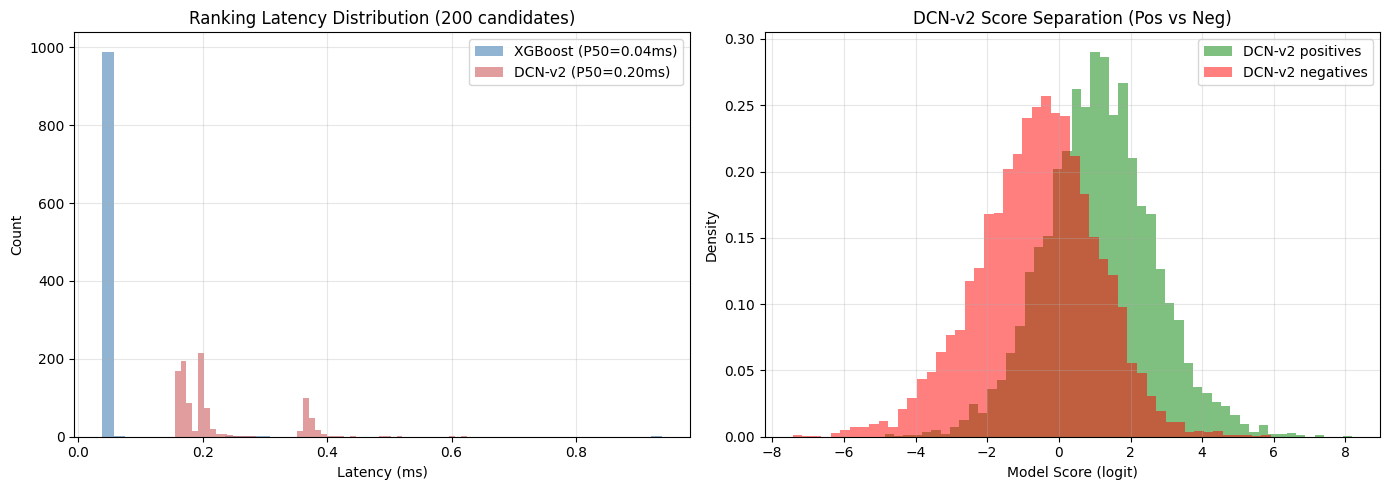

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(xgb_latencies, bins=50, alpha=0.6, label=f'XGBoost (P50={np.median(xgb_latencies):.2f}ms)', color='steelblue')
axes[0].hist(dcn_latencies, bins=50, alpha=0.6, label=f'DCN-v2 (P50={np.median(dcn_latencies):.2f}ms)', color='indianred')
axes[0].set_xlabel('Latency (ms)')
axes[0].set_ylabel('Count')
axes[0].set_title(f'Ranking Latency Distribution ({N_CANDIDATES} candidates)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Score distributions
axes[1].hist(dcn_test_scores[y_test == 1][:5000], bins=50, alpha=0.5, label='DCN-v2 positives', color='green', density=True)
axes[1].hist(dcn_test_scores[y_test == 0][:5000], bins=50, alpha=0.5, label='DCN-v2 negatives', color='red', density=True)
axes[1].set_xlabel('Model Score (logit)')
axes[1].set_ylabel('Density')
axes[1].set_title('DCN-v2 Score Separation (Pos vs Neg)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../plots/dcn_v2_latency_and_scores.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 10: Cross Network Ablation

To verify the cross network is contributing (not just the deep MLP doing all the work), we measure the impact of removing it. This is a key ablation for understanding whether explicit feature interactions provide value over implicit representations alone.

In [18]:
class DeepOnlyBaseline(nn.Module):
    """Same deep network as DCN-v2 but without the cross network.
    
    This measures the contribution of the cross network. If DCN-v2 and
    DeepOnly have similar performance, the cross layers add no value.
    """
    def __init__(self, input_dim: int, hidden_dims: List[int], dropout: float):
        super().__init__()
        self.deep_network = DeepNetwork(input_dim, hidden_dims, dropout)
        self.output_layer = nn.Linear(hidden_dims[-1], 1)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        deep_out = self.deep_network(x)
        return self.output_layer(deep_out).squeeze(-1)


# Train a deep-only baseline for comparison
deep_only_model = DeepOnlyBaseline(
    input_dim=INPUT_DIM, hidden_dims=DEEP_HIDDEN_DIMS, dropout=DROPOUT
).to(device)

deep_only_optimizer = torch.optim.AdamW(deep_only_model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
deep_only_scheduler = OneCycleLR(deep_only_optimizer, max_lr=LEARNING_RATE,
                                  total_steps=len(train_loader) * 15,
                                  pct_start=0.1, anneal_strategy='cos')

print('Training Deep-Only ablation baseline (15 epochs max)...')
best_deep_ndcg = -1

for epoch in range(15):
    deep_only_model.train()
    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)
        scores = deep_only_model(batch_X)
        loss = BPR_ALPHA * F.binary_cross_entropy_with_logits(scores, batch_y) + \
               (1 - BPR_ALPHA) * compute_bpr_loss(scores, batch_y)
        deep_only_optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(deep_only_model.parameters(), GRAD_CLIP_NORM)
        deep_only_optimizer.step()
        deep_only_scheduler.step()
    
    deep_only_model.eval()
    with torch.no_grad():
        val_tensor = torch.tensor(X_val, dtype=torch.float32).to(device)
        val_scores_deep = deep_only_model(val_tensor).cpu().numpy()
        del val_tensor
    
    val_ndcg_deep = compute_ndcg_at_k(val_scores_deep, y_val, val_user_idxs, k=10)
    if val_ndcg_deep > best_deep_ndcg:
        best_deep_ndcg = val_ndcg_deep
        torch.save(deep_only_model.state_dict(), MODEL_DIR / 'deep_only_ablation.pt')
    
    if (epoch + 1) % 5 == 0:
        print(f'  Epoch {epoch+1}: val NDCG@10 = {val_ndcg_deep:.4f}')

# Evaluate deep-only on test
deep_only_model.load_state_dict(torch.load(MODEL_DIR / 'deep_only_ablation.pt', map_location=device, weights_only=True))
deep_only_model.eval()
with torch.no_grad():
    test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
    deep_only_test_scores = deep_only_model(test_tensor).cpu().numpy()
    del test_tensor

deep_only_auc = roc_auc_score(y_test, deep_only_test_scores)
deep_only_ndcg = compute_ndcg_at_k(deep_only_test_scores, y_test, test_user_idxs, k=10)

print(f'\n{"="*60}')
print(f'ABLATION: Cross Network Contribution')
print(f'{"="*60}')
print(f'{"Model":<20}{"Test AUC":<12}{"Test NDCG@10":<15}')
print('-' * 47)
print(f'{"Deep-Only (MLP)":<20}{deep_only_auc:<12.4f}{deep_only_ndcg:<15.4f}')
print(f'{"DCN-v2 (full)":<20}{dcn_test_auc:<12.4f}{dcn_test_ndcg:<15.4f}')
print(f'{"Cross net uplift":<20}{dcn_test_auc - deep_only_auc:<+12.4f}{dcn_test_ndcg - deep_only_ndcg:<+15.4f}')
print(f'\nThe cross network contribution shows whether explicit polynomial')
print(f'feature interactions add value beyond what the deep MLP learns implicitly.')

Training Deep-Only ablation baseline (15 epochs max)...


/Users/nipun.batra/Downloads/ML/DCN-v2_Recommendation/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


  Epoch 5: val NDCG@10 = 0.8755


  Epoch 10: val NDCG@10 = 0.8768


  Epoch 15: val NDCG@10 = 0.8794

ABLATION: Cross Network Contribution
Model               Test AUC    Test NDCG@10   
-----------------------------------------------
Deep-Only (MLP)     0.7618      0.8724         
DCN-v2 (full)       0.7560      0.8698         
Cross net uplift    -0.0058     -0.0025        

The cross network contribution shows whether explicit polynomial
feature interactions add value beyond what the deep MLP learns implicitly.


## Section 11: End-to-End Pipeline Demo

Same demo as the XGBoost notebook: FAISS retrieval + DCN-v2 re-ranking for individual users.

In [19]:
import faiss

index = faiss.read_index(str(MODEL_DIR / 'faiss_index_128dim.bin'))
movies_df = pd.read_csv('../data/ml-25m/movies.csv')
movie_titles = dict(zip(movies_df['movieId'], movies_df['title']))
movie_genres = dict(zip(movies_df['movieId'], movies_df['genres']))


def recommend_dcn_v2(user_id: int, top_k: int = 10, n_candidates: int = 200):
    """Full inference: FAISS retrieval -> DCN-v2 re-ranking."""
    user_idx = user2idx.get(user_id)
    if user_idx is None:
        print(f'User {user_id} not found')
        return
    
    t0 = time.perf_counter()
    
    # FAISS retrieval
    user_emb = user_embeddings[user_idx:user_idx+1]
    scores, positions = index.search(user_emb, n_candidates)
    candidate_idxs = positions[0]
    retrieval_scores = scores[0]
    
    # Build feature vector
    n_cands = len(candidate_idxs)
    n_features = 1 + len(user_feat_cols) + len(item_feat_cols) + 7
    X_cand = np.zeros((n_cands, n_features), dtype=np.float32)
    X_cand[:, 0] = retrieval_scores
    X_cand[:, 1:1+len(user_feat_cols)] = user_feat_matrix[user_idx]
    X_cand[:, 1+len(user_feat_cols):1+len(user_feat_cols)+len(item_feat_cols)] = item_feat_matrix[candidate_idxs]
    user_genre_prefs = user_feat_matrix[user_idx, 4:23]
    X_cand[:, -7] = item_feat_matrix[candidate_idxs, :19] @ user_genre_prefs
    X_cand[:, -6] = item_feat_matrix[candidate_idxs, 20] - user_feat_matrix[user_idx, 23]
    
    # DCN-v2 scoring
    with torch.no_grad():
        cand_tensor = torch.tensor(X_cand, dtype=torch.float32)
        ranker_scores = model_cpu(cand_tensor).numpy()
    
    # Top-K
    top_indices = np.argsort(ranker_scores)[::-1][:top_k]
    latency = (time.perf_counter() - t0) * 1000
    
    print(f'\nRecommendations for User {user_id} (DCN-v2, latency: {latency:.1f}ms):')
    print(f'{"Rank":<6}{"Score":<10}{"Title":<50}{"Genres"}')
    print('-' * 96)
    for rank, idx in enumerate(top_indices, 1):
        midx = candidate_idxs[idx]
        if midx == 0:
            continue
        mid = idx2movie[midx]
        title = movie_titles.get(mid, f'id={mid}')[:49]
        genres = movie_genres.get(mid, '')[:30]
        print(f'{rank:<6}{ranker_scores[idx]:<10.3f}{title:<50}{genres}')


recommend_dcn_v2(1)
recommend_dcn_v2(100)
recommend_dcn_v2(1000)


Recommendations for User 1 (DCN-v2, latency: 2.8ms):
Rank  Score     Title                                             Genres
------------------------------------------------------------------------------------------------
1     3.073     Eternal Sunshine of the Spotless Mind (2004)      Drama|Romance|Sci-Fi
2     3.001     Lives of Others, The (Das leben der Anderen) (200 Drama|Romance|Thriller
3     2.968     Spirited Away (Sen to Chihiro no kamikakushi) (20 Adventure|Animation|Fantasy
4     2.748     Pianist, The (2002)                               Drama|War
5     2.697     Decalogue, The (Dekalog) (1989)                   Crime|Drama|Romance
6     2.640     Once (2006)                                       Drama|Musical|Romance
7     2.632     Amelie (Fabuleux destin d'Amélie Poulain, Le) (20 Comedy|Romance
8     2.630     Sea Inside, The (Mar adentro) (2004)              Drama
9     2.600     Best of Youth, The (La meglio gioventù) (2003)    Drama
10    2.515     Little Miss Sun

## Section 12: Summary

### Model Artifacts Produced

| File | Size | Description |
|------|------|-------------|
| `models/dcn_v2_ranker.pt` | ~0.4 MB | Trained DCN-v2 state dict |
| `models/dcn_v2_config.json` | <1 KB | Architecture and training config |
| `models/dcn_v2_training_history.pkl` | <10 KB | Per-epoch loss and metrics |
| `models/deep_only_ablation.pt` | ~0.2 MB | Ablation baseline (no cross network) |

### Key Results

The comparison table above shows DCN-v2 vs XGBoost on the held-out test set with proper statistical testing:
- FDR-corrected significance at alpha=0.05
- Bootstrap 95% confidence intervals for the difference
- Cohen's d effect sizes for practical significance

### Next Steps

- **Notebook 05**: Comprehensive evaluation including end-to-end pipeline metrics, cohort analysis, calibration, and diversity
- **Notebook 07**: DCN-v2 trained on ComiRec features (109-dim with 5 retrieval scores)
- **Notebook 10**: DCN-v2 trained on SASRec features
- **Notebook 12**: Production serving with DCN-v2